<h1 style="color:orange; font-weight:bold">Bank Marketing Subscription Prediction</h1>


<h1 style="color:orange; font-weight:bold">Step 1 — Dataset</h1>

<h3 style="color:green; font-weight:bold">1.1 — Data Uploading</h3>

In [131]:
# Import the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("bank-full.csv", sep=";")

# Display the first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [132]:
# Display the number of rows and columns
df.shape

(45211, 17)

<h1 style="color:orange; font-weight:bold">Step 2 — Data Understanding</h1>

<h3 style="color:green; font-weight:bold">2.1 — Dataset Overview</h3>

| # | Question |
|---|----------|
| Q1 | How many rows and columns are present in the dataset? |
| Q2 | What are the names of all features? |
| Q3 | What are the data types of the features? |
| Q4 | Which features are numerical and which are categorical? |
| Q5 | Are there any missing values? |
| Q6 | Are there any duplicate rows? |
| Q7 | What are the unique values in the target variable? |
| Q8 | What is the distribution of the target variable? |
| Q9 | What are the basic statistical properties of the numerical features? |
| Q10 | What are the unique values of the categorical features? |

In [133]:
# Display all column names in the dataset
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [134]:
# Display data types and non-null information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [135]:
# Display unique values of the target variable
df["y"].unique()

array(['no', 'yes'], dtype=object)

In [136]:
# Display the distribution of the target variable
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [137]:
# Select and display numerical columns
numeric_features = df.select_dtypes(include="number").columns

numeric_features


# Select and display categorical columns
categorical_features = df.select_dtypes(include="object").columns

categorical_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [138]:
# Display unique values of each categorical feature
for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].unique())


job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
['married' 'single' 'divorced']

education:
['tertiary' 'secondary' 'unknown' 'primary']

default:
['no' 'yes']

housing:
['yes' 'no']

loan:
['no' 'yes']

contact:
['unknown' 'cellular' 'telephone']

month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
['unknown' 'failure' 'other' 'success']

y:
['no' 'yes']


<h1 style="color:orange; font-weight:bold">Step 3 — Exploratory Data Analysis (EDA)</h1>

<h3 style="color:green; font-weight:bold">3.1 — EDA Questions</h3>

| # | Question |
|---|----------|
| Q1 | How is the target variable distributed? |
| Q2 | What do the numerical features look like? |
| Q3 | Are there any obvious outliers in the numerical features? |
| Q4 | How do the important numerical features differ between target classes? |
| Q5 | What are the common categories in the categorical features? |
| Q6 | Which categorical features show differences in subscription across categories? |
| Q7 | Are there strong relationships between numerical features? |
| Q8 | Are there any features that may not be available at prediction time? |

<h3 style="color:green; font-weight:bold">3.2 — Target Variable Analysis</h3>

In [139]:
# Display the count of each target class
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [140]:
# Calculate the percentage of each target class
df["y"].value_counts(normalize=True).mul(100).round(2)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64

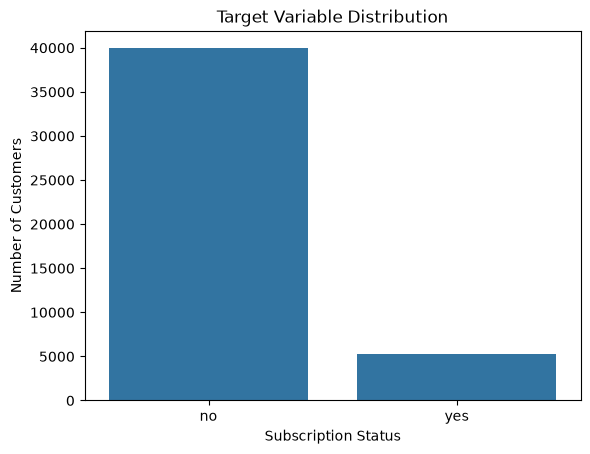

In [141]:
# Visualize the target variable distribution
sns.countplot(data=df, x="y")

# Add labels to the chart
plt.title("Target Variable Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

<h3 style="color:green; font-weight:bold">3.3 — Numerical Feature Analysis</h3>

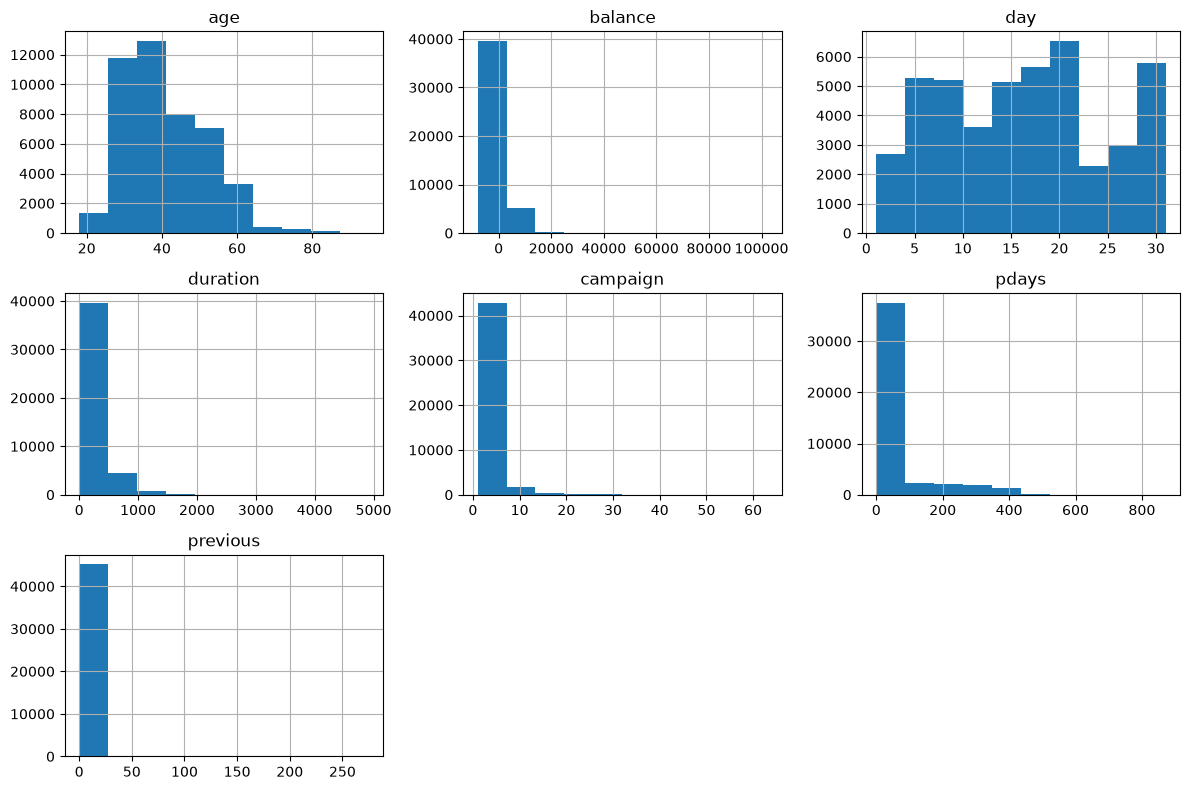

In [142]:
# Display the distribution of numerical features
df[numeric_features].hist(figsize=(12, 8))

# Adjust the layout
plt.tight_layout()

# Display the charts
plt.show()

<h3 style="color:green; font-weight:bold">3.4 — Outlier Analysis</h3>

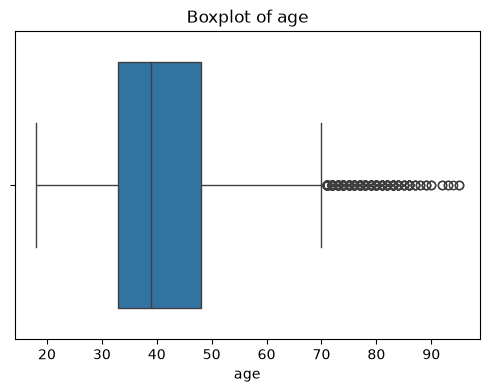

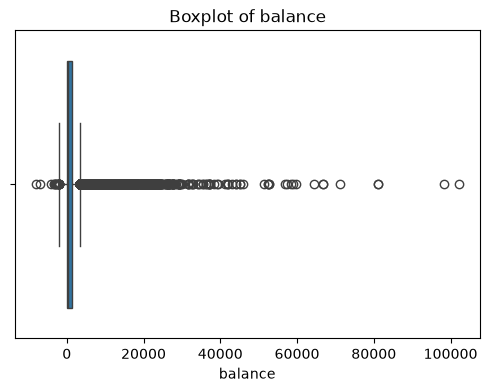

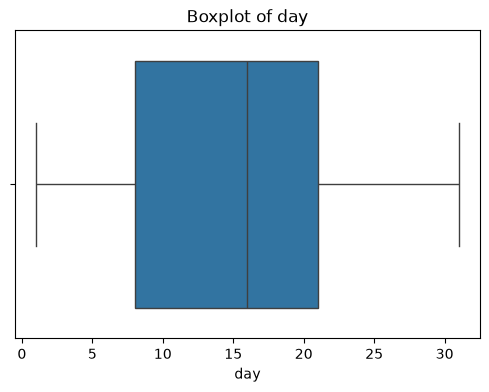

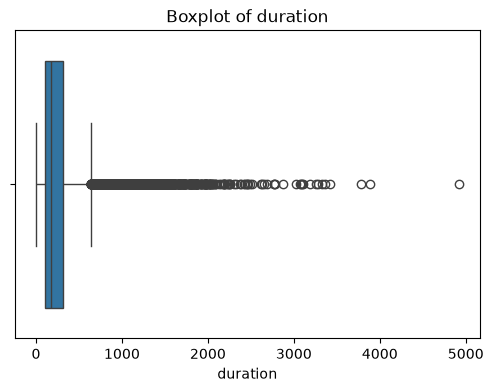

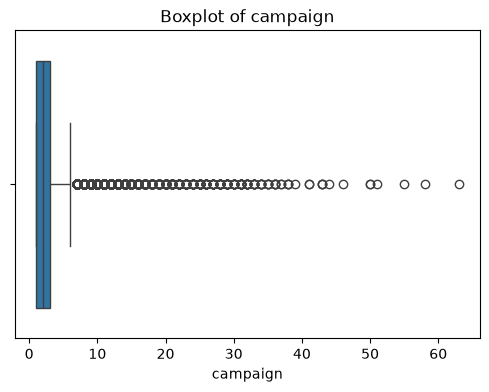

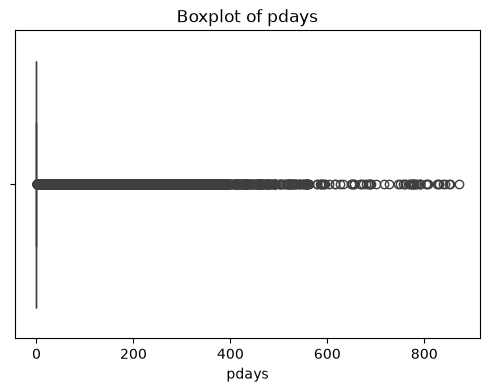

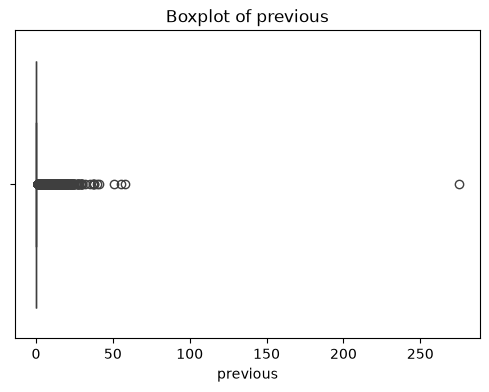

In [143]:
# Create boxplots to identify potential outliers
for column in numeric_features:
    plt.figure(figsize=(6, 4))
    
    # Plot the feature
    sns.boxplot(data=df, x=column)
    
    # Add chart title
    plt.title(f"Boxplot of {column}")
    
    # Display the chart
    plt.show()

<h3 style="color:green; font-weight:bold">3.5 — Numerical Features vs Target</h3>

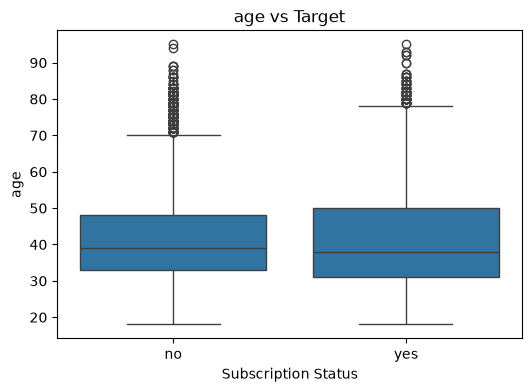

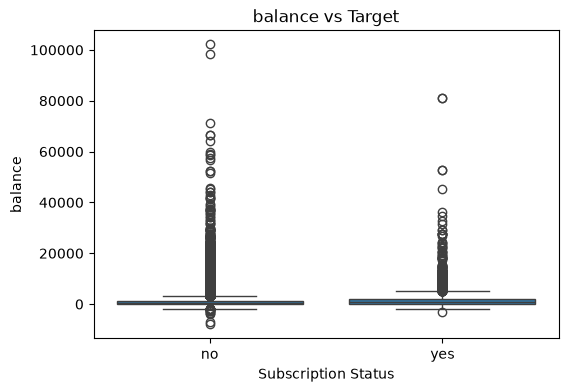

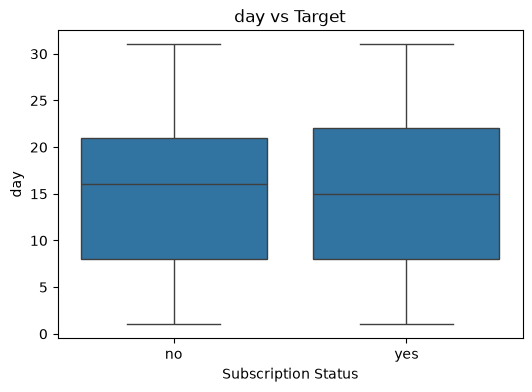

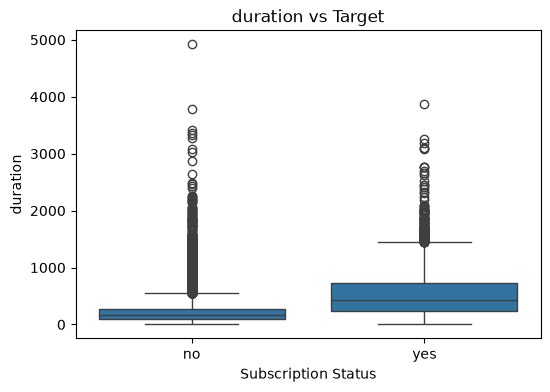

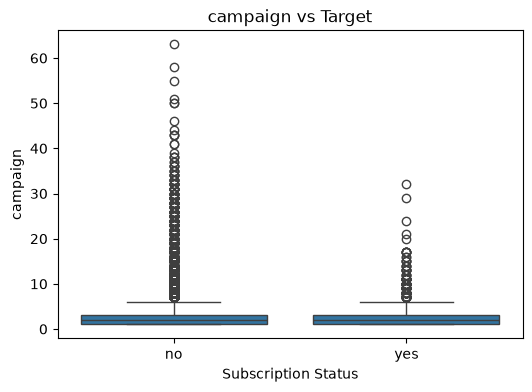

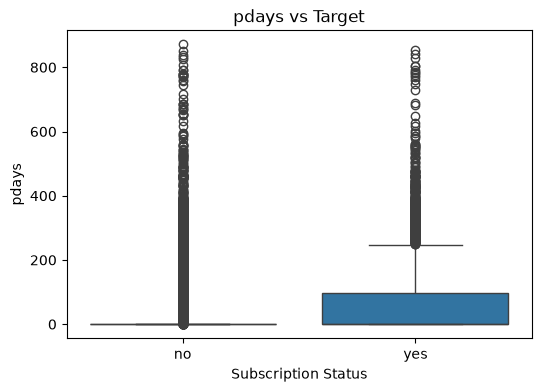

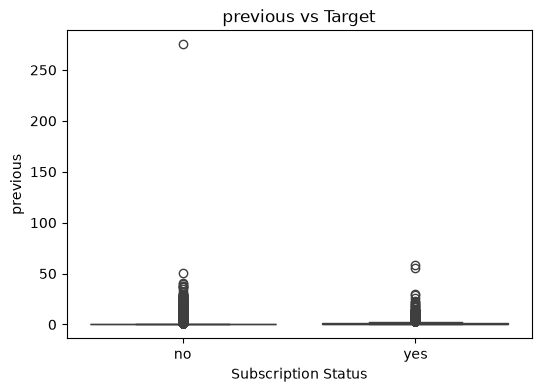

In [144]:
# Compare numerical features across target classes
for column in numeric_features:
    plt.figure(figsize=(6, 4))
    
    # Create a boxplot for each numerical feature
    sns.boxplot(data=df, x="y", y=column)
    
    # Add chart labels
    plt.title(f"{column} vs Target")
    plt.xlabel("Subscription Status")
    plt.ylabel(column)
    
    # Display the chart
    plt.show()

<h3 style="color:green; font-weight:bold">3.6 — Categorical Feature Analysis</h3>

In [145]:
# Display the frequency of categories in each categorical feature
for column in categorical_features:
    if column != "y":
        
        print(f"\n{column}")
        print(df[column].value_counts())


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

<h3 style="color:green; font-weight:bold">3.7 — Categorical Features vs Target</h3>

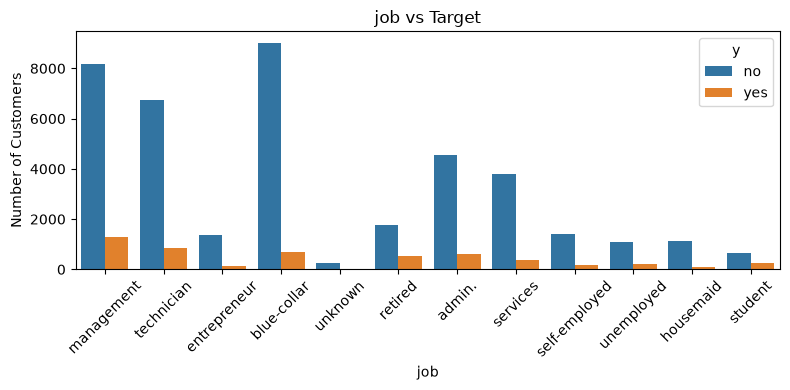

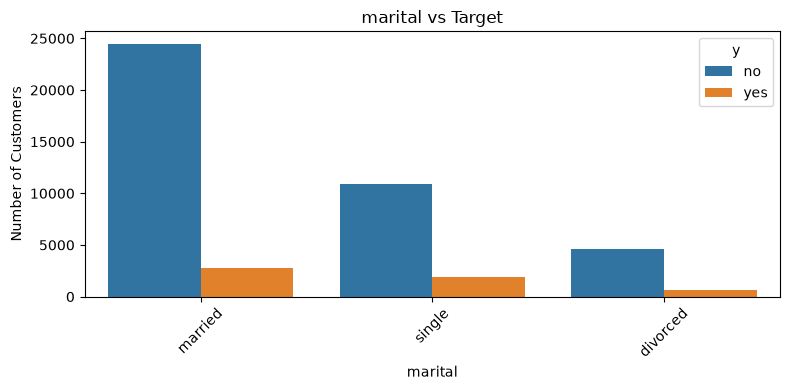

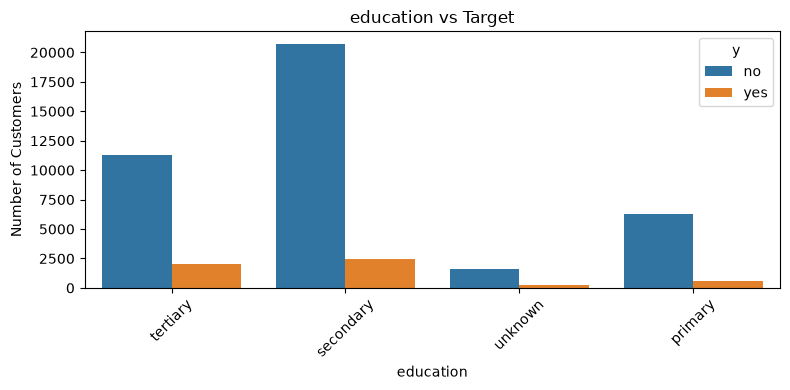

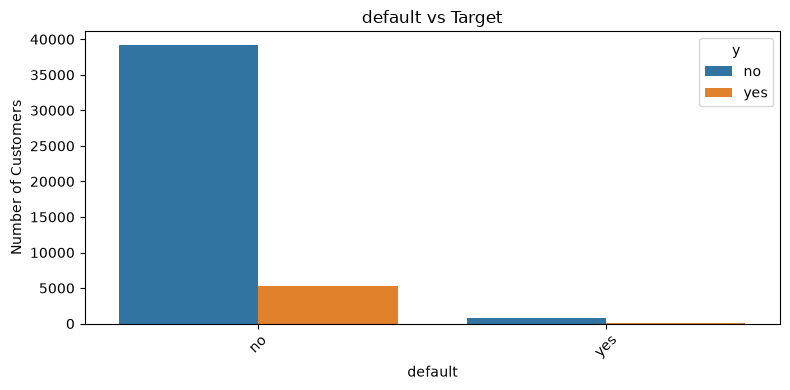

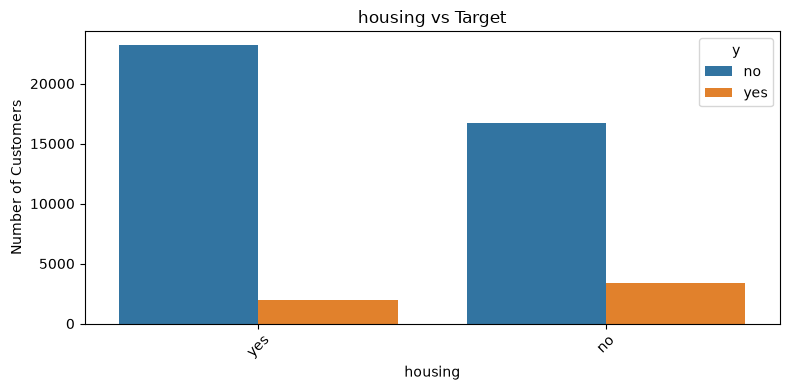

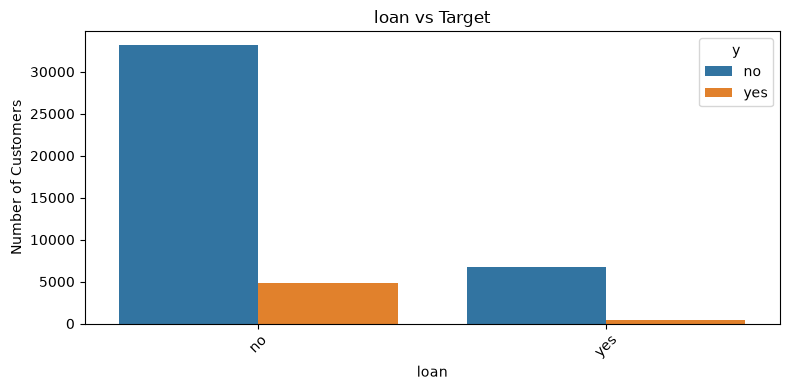

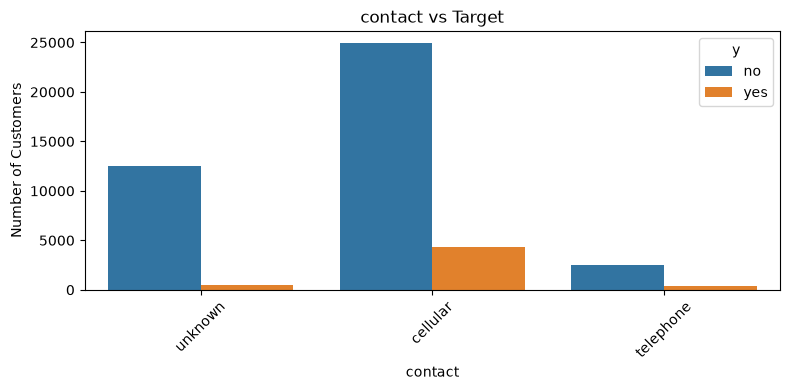

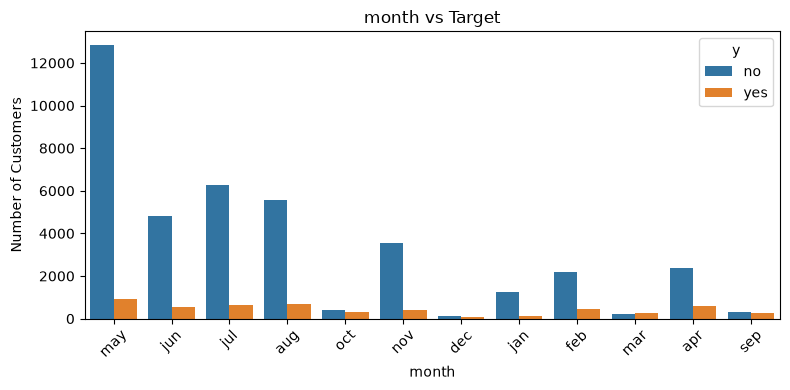

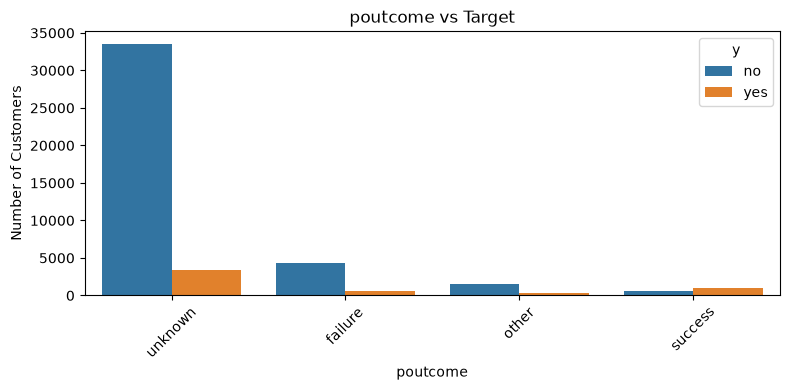

In [146]:
# Compare categorical features with the target variable
for column in categorical_features:
    if column != "y":
        
        plt.figure(figsize=(8, 4))
        
        # Show target distribution for each category
        sns.countplot(data=df, x=column, hue="y")
        
        # Add chart labels
        plt.title(f"{column} vs Target")
        plt.xlabel(column)
        plt.ylabel("Number of Customers")
        
        # Rotate labels for readability
        plt.xticks(rotation=45)
        
        # Adjust the layout
        plt.tight_layout()
        
        # Display the chart
        plt.show()

<h3 style="color:green; font-weight:bold">3.8 — Correlation Analysis</h3>

In [147]:
# Calculate correlations between numerical features
correlation_matrix = df[numeric_features].corr()

# Display the correlation matrix
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


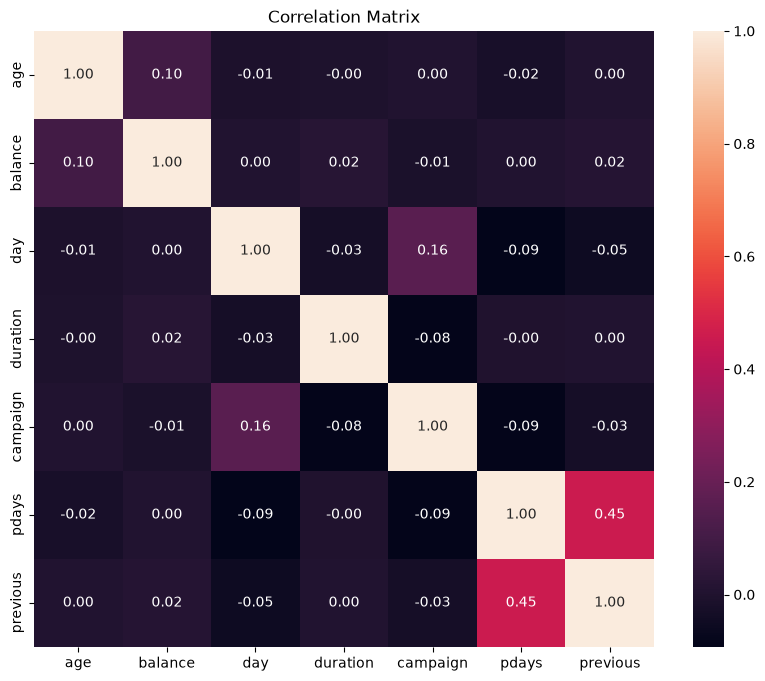

In [148]:
# Visualize correlations between numerical features
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

# Add chart title
plt.title("Correlation Matrix")

# Display the chart
plt.show()

<h3 style="color:green; font-weight:bold">3.9 — Prediction-Time Feature Check</h3>

In [149]:
# Review the call duration feature
df[["duration", "y"]].head()

,duration,y
0,261,no
1,151,no
2,76,no
3,92,no
4,198,no


In [150]:
# Compare call duration across target classes
df.groupby("y")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


<h1 style="color:orange; font-weight:bold">Step 4 — Data Cleaning</h1>

<h3 style="color:green; font-weight:bold">4.1 — Data Cleaning Questions</h3>

| # | Question |
|---|----------|
| Q1 | Are there any missing values that need treatment? |
| Q2 | Are there any duplicate rows that need to be removed? |
| Q3 | Are there any placeholder values such as "unknown" that need a decision? |
| Q4 | Are there any invalid or suspicious values in numerical features? |
| Q5 | Is the dataset ready for feature engineering and preprocessing? |

In [151]:
# Count total missing values in the dataset
df.isnull().sum().sum()

np.int64(0)

In [152]:
# Display columns that contain missing values
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [153]:
# Count duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [154]:
# Display the new dataset shape
df.shape

(45211, 17)

In [155]:
# Check how many "unknown" values exist in each categorical feature
for column in categorical_features:
    unknown_count = (df[column] == "unknown").sum()
    
    if unknown_count > 0:
        print(f"{column}: {unknown_count}")

job: 288
education: 1857
contact: 13020
poutcome: 36959


<h3 style="color:green; font-weight:bold">4.3 — Numerical Value Validation</h3>

In [156]:
# Display minimum and maximum values of numerical features
df[numeric_features].agg(["min", "max"]).T

,min,max
age,18,95
balance,-8019,102127
day,1,31
duration,0,4918
campaign,1,63
pdays,-1,871
previous,0,275


In [157]:
# Check whether any numerical feature contains negative values
(df[numeric_features] < 0).sum().sort_values(ascending=False)

pdays       36954
balance      3766
age             0
day             0
duration        0
campaign        0
previous        0
dtype: int64

In [158]:
# Display the final dataset information after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Observations

- Missing values = 0, so no missing-value treatment is required.
- Duplicate rows = 0, so no duplicate removal is required.
- "unknown" values are present in four categorical features and will be handled during preprocessing.
- Negative `balance` values are present and are valid values, so they should not be removed.
- `pdays` contains `-1` values, which indicates a special category that needs to be handled before modeling.
- The numerical features contain different value ranges, so feature scaling will be considered during preprocessing.
- `duration` ranges from 0 to 4918 and must be considered carefully because it is related to the outcome after the contact occurs.

<h1 style="color:orange; font-weight:bold">Step 5 — Feature Engineering</h1>

<h3 style="color:green; font-weight:bold">5.1 — Feature Engineering Questions</h3>

| # | Question |
|---|----------|
| Q1 | Which features should be removed before modeling? |
| Q2 | Should `pdays = -1` be treated as a special condition? |
| Q3 | Can we create a useful feature from `pdays`? |
| Q4 | What will be our final feature set before splitting the data? |

<h3 style="color:green; font-weight:bold">5.2 — Remove Target Leakage</h3>

In [159]:
# Remove duration because it is known after the customer interaction
# and can cause target leakage during prediction
df = df.drop(columns=["duration"])

# Display the updated feature list
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'y'],
      dtype='object')

<h3 style="color:green; font-weight:bold">5.3 — Handle `pdays`</h3>

In [160]:
# Create a new feature to indicate whether the customer was contacted before
df["previously_contacted"] = (df["pdays"] != -1).astype(int)

# Display the new feature values
df["previously_contacted"].value_counts()

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

<h3 style="color:green; font-weight:bold">5.4 — Replace Special Values in `pdays`</h3>

In [161]:
# Replace -1 with NaN because -1 means the customer was not previously contacted
df["pdays"] = df["pdays"].replace(-1, np.nan)

# Check the result
df["pdays"].isnull().sum()

np.int64(36954)

<h3 style="color:green; font-weight:bold">Feature Engineering — Observation</h3>

- `duration` was removed to avoid target leakage.
- A new `previously_contacted` feature was created from `pdays`.
- `pdays = -1` was replaced with `NaN` so it can be handled by the preprocessing pipeline.

<h1 style="color:orange; font-weight:bold">Step 6 — Baseline Model </h1>

In [162]:
# Import tools for building the preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression

In [163]:
X = df.drop('y', axis=1)

# Encode target: no = 0, yes = 1
y = df['y'].map({'no': 0, 'yes': 1})

In [164]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [165]:
# Display the shapes of the training and testing sets
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 16)
X_test: (9043, 16)
y_train: (36168,)
y_test: (9043,)


In [166]:
# Check the target distribution in the training set
print("Training Target Distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training Target Distribution:
y
0    0.883
1    0.117
Name: proportion, dtype: float64


<h3 style="color:green; font-weight:bold">Train-Test Split — Observation</h3>

- Training set: 36,168 samples
- Testing set: 9,043 samples
- 16 input features are present in both sets.
- Target distribution is identical in both sets:
  - `no` = 88.3%
  - `yes` = 11.7%
- Stratification worked correctly.
- The dataset is imbalanced, so this will be considered during model building and evaluation.

In [167]:
# Identify numerical features for the preprocessing pipeline
numeric_features = X.select_dtypes(include="number").columns

# Identify categorical features for the preprocessing pipeline
categorical_features = X.select_dtypes(include="object").columns

In [168]:
# Fill missing numerical values with the median
# Then scale numerical features using StandardScaler
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# Fill missing categorical values with the most frequent value
# Then convert categorical values into numerical form
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])



In [169]:
# Apply the numerical pipeline to numerical features
# Apply the categorical pipeline to categorical features
preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)])

In [170]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))])

In [171]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'previous','poutcome','previously_contacted']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [172]:
y_test_pred = baseline_model.predict(X_train)

In [173]:
metrics = {
    "Accuracy": accuracy_score(y_train, y_test_pred),
    "Precision": precision_score(y_train, y_test_pred, pos_label=1, zero_division=0),
    "Recall": recall_score(y_train, y_test_pred, pos_label=1, zero_division=0),
    "F1 Score": f1_score(y_train, y_test_pred, pos_label=1, zero_division=0)
}

for name, value in metrics.items():
    print(f"{name:<10}: {value:.4f}")

Accuracy  : 0.8923
Precision : 0.6461
Recall    : 0.1756
F1 Score  : 0.2762


<h3 style="color:Blue; font-weight:bold">Baseline Model — Observation</h3>

- Accuracy = 89.35%, but accuracy alone is not sufficient because the target is imbalanced.
- Precision for `yes` = 66.78%.
- Recall for `yes` = 17.86%, which is low.
- F1 Score for `yes` = 28.19%.
- The model identifies most `no` cases well, but misses many customers who actually subscribe (`yes`).
- Therefore, the next models should be compared using metrics such as Precision, Recall, and F1 Score rather than accuracy alone.

<h1 style="color:orange; font-weight:bold">Step 9 — Multiple Model Training</h1>

<h3 style="color:green; font-weight:bold">9.1 — Model Selection Questions</h3>

| # | Question |
|---|----------|
| Q1 | Which classification models should we compare for this problem? |
| Q2 | Why should we compare multiple models instead of using only Logistic Regression? |
| Q3 | Can we use the same preprocessing pipeline for all models? |
| Q4 | How do the selected models perform on the test set? |
| Q5 | Which model provides a better balance of Precision, Recall, and F1 Score for the `yes` class? |

In [174]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import make_scorer

In [175]:
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'recall': make_scorer(recall_score, pos_label=1, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=1, zero_division=0)
}

In [176]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42,verbosity=-1),
    "Naive Bayes":GaussianNB()
    }

In [177]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Use stratified 5-fold cross-validation to preserve the target distribution
# in every validation fold.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    pipeline = Pipeline([("preprocessor", preprocessor),("model", model)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')

    results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean()})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="CV F1", ascending=False).reset_index(drop=True)

<h3 style="color:green; font-weight:bold">9.3 — Best Model Selection</h3>

| # | Question |
|---|----------|
| Q1 | Which model achieved the highest cross-validated F1 Score? |
| Q2 | Why was F1 Score used instead of Accuracy for selecting the model? |
| Q3 | Which model will be used for hyperparameter tuning? |

In [178]:
# Select the model with the highest cross-validated F1 Score.
# F1 is the primary metric because the target is imbalanced
# and we want a balance between Precision and Recall for the "yes" class.

print("\n========== BASIC CLASSIFICATION RESULTS ==========\n")
print(results_df)

best_model_name = results_df.loc[0, "Model"]
best_cv_f1 = results_df.loc[0, "CV F1"]

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

print("\n================================")
print("Best Model       :", best_model_name)
print("Best CV F1       :", best_cv_f1)


========== BASIC CLASSIFICATION RESULTS ==========

                   Model  CV Accuracy  CV Precision  CV Recall     CV F1
0            Naive Bayes     0.831343      0.337455   0.457339  0.388188
1                XGBoost     0.891617      0.580457   0.264477  0.363146
2               LightGBM     0.893884      0.618832   0.241788  0.347630
3   HistGradientBoosting     0.893552      0.619005   0.234225  0.339774
4            Extra Trees     0.882852      0.498043   0.256910  0.338742
5          Random Forest     0.892170      0.603644   0.227133  0.329966
6      Gradient Boosting     0.894465      0.655815   0.206808  0.314272
7          Decision Tree     0.828384      0.291416   0.327114  0.308147
8                    KNN     0.885341      0.524422   0.210114  0.299915
9                    SVC     0.893082      0.654711   0.181755  0.284355
10   Logistic Regression     0.892253      0.646146   0.175139  0.275328

Best Model       : Naive Bayes
Best CV F1       : 0.3881877689071218


### Observation

The target variable is imbalanced, with significantly more `no` cases than `yes` cases.

Therefore, Accuracy alone is not sufficient for model selection because a model can achieve high accuracy while still missing many customers who actually subscribe.

We use **F1 Score as the primary model-selection metric** because F1 balances **Precision and Recall** for the minority `yes` class.

Based on 5-fold cross-validation:

- **Naive Bayes** achieved the highest CV F1 Score of **0.3882**.
- Therefore, Naive Bayes is selected for hyperparameter tuning.
- Accuracy, Precision, and Recall will still be considered during the final evaluation.

<h1 style="color:orange; font-weight:bold">Step 11 — Hyperparameter Tuning</h1>

<h3 style="color:green; font-weight:bold">10.1 — Naive Bayes Hyperparameter Tuning</h3>

| # | Question |
|---|----------|
| Q1 | Why do we tune the hyperparameters of the selected model? |
| Q2 | Which hyperparameter of Naive Bayes should we tune? |
| Q3 | Which hyperparameter combination gives the highest cross-validated F1 Score? |

In [179]:
# Define hyperparameter grids
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear", "lbfgs"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "SVC": {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Extra Trees": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5]
    },

    "HistGradientBoosting": {
        "model__max_iter": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0, 1]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [-1, 5, 10]
    },

    "Naive Bayes": {
        "model__var_smoothing": [1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 1e-04, 1e-03]}
    }

In [180]:
grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grids[best_model_name],
    scoring=scoring["f1"],
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...aussianNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__var_smoothing': [1e-09, 1e-08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [181]:
print("\n========== HYPERPARAMETER TUNING RESULTS ==========\n")

print("Best Model                    :", best_model_name)
print("Best Parameters               :", grid_search.best_params_)
print("Best CV F1                    :", grid_search.best_score_)


========== HYPERPARAMETER TUNING RESULTS ==========

Best Model                    : Naive Bayes
Best Parameters               : {'model__var_smoothing': 1e-05}
Best CV F1                    : 0.38818837662386335


<h1 style="color:orange; font-weight:bold">Step 11 — Final Model Evaluation</h1>

<h3 style="color:green; font-weight:bold">11.1 — Final Model Questions</h3>

| # | Question |
|---|----------|
| Q1 | How does the final tuned model perform on unseen test data? |
| Q2 | What are the Accuracy, Precision, Recall, and F1 Score of the final model? |
| Q3 | How many customers are correctly and incorrectly classified? |
| Q4 | How does the final test performance compare with the cross-validated performance? |

In [182]:
from IPython.display import display

# Get the best fitted pipeline found by GridSearchCV
final_model = grid_search.best_estimator_

display(final_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'previous','poutcome','previously_contacted']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [183]:
# Generate predictions on the untouched test set.

y_test_pred = final_model.predict(X_test)

In [184]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate final evaluation metrics on unseen test data.
# The positive class is encoded as 1.

test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    pos_label=1,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    pos_label=1,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    pos_label=1,
    zero_division=0
)

print("========== FINAL TEST RESULTS ==========")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

========== FINAL TEST RESULTS ==========
Accuracy  : 0.8371
Precision : 0.3529
Recall    : 0.4707
F1 Score  : 0.4034


In [185]:
from sklearn.metrics import confusion_matrix

# Create the confusion matrix for the two encoded classes.
# 0 = no, 1 = yes.

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7072  913]
 [ 560  498]]


<h3 style="color:green; font-weight:bold">11.2 — Classification Report</h3>

| # | Question |
|---|----------|
| Q1 | How does the final model perform for each target class? |
| Q2 | How do Precision, Recall, and F1 Score differ between the `no` and `yes` classes? |
| Q3 | What does the model's performance on the `yes` class tell us about subscription prediction? |

In [186]:
from sklearn.metrics import classification_report

# Generate a detailed classification report for both classes.

report = classification_report(
    y_test,
    y_test_pred,
    target_names=["no", "yes"],
    zero_division=0
)

print("========== CLASSIFICATION REPORT ==========")
print(report)

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

          no       0.93      0.89      0.91      7985
         yes       0.35      0.47      0.40      1058

    accuracy                           0.84      9043
   macro avg       0.64      0.68      0.65      9043
weighted avg       0.86      0.84      0.85      9043



<h3 style="color:green; font-weight:bold">11.3 — ROC-AUC and PR-AUC</h3>

| # | Question |
|---|----------|
| Q1 | How well does the model distinguish between customers who subscribe and those who do not? |
| Q2 | What is the ROC-AUC score of the final model? |
| Q3 | What is the PR-AUC score of the final model? |
| Q4 | Why is PR-AUC particularly useful for this imbalanced classification problem? |

In [187]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Get predicted probabilities for the positive class (1 = yes).

y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC and PR-AUC.

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

print("========== PROBABILITY-BASED METRICS ==========")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

========== PROBABILITY-BASED METRICS ==========
ROC-AUC : 0.7509
PR-AUC  : 0.3533


### Observation 1 — Class Imbalance

- The target variable is imbalanced, with **7,985 `no` cases** and only **1,058 `yes` cases**.
- The `yes` class represents only about **12%** of the test data.
- This imbalance makes it harder for the model to correctly identify customers who subscribe.
- Therefore, Accuracy alone is not sufficient, and Precision, Recall, F1 Score, and PR-AUC are important for evaluating the `yes` class.

### Observation 2 — Final Model Performance

- The final model achieved an **F1 Score of 40.34%** and **Recall of 47.07%** for the `yes` class.
- This means the model identifies less than half of the actual subscribing customers.
- The **ROC-AUC of 0.7509** and **PR-AUC of 0.3533** show that the model has useful predictive signal, but there is still room for improvement.
- Therefore, we will now investigate whether **class imbalance handling and better feature engineering** can improve the model's performance before moving to deployment.

<h1 style="color:orange; font-weight:bold">Step 12 — Focused Model Improvement</h1>

<h3 style="color:green; font-weight:bold">12.1 Improvement Plan</h3>

| Question | What we need to find out |
|---|---|
| Q1 | How can we handle the class imbalance in the training data? |
| Q2 | Can simple domain-based feature engineering improve the predictive signal? |
| Q3 | Which models perform better after class imbalance handling and feature engineering? |
| Q4 | Does the improved approach achieve a better CV F1 Score? |
| Q5 | Does the improved model beat our current test F1 benchmark of 0.4034? |

In [214]:
# Store the current final test F1 score as our benchmark
baseline_test_f1 = 0.4034

print("Current Benchmark Test F1:", baseline_test_f1)

Current Benchmark Test F1: 0.4034


<h3 style="color:green; font-weight:bold">12.2 Class Imbalance Handling</h3>

In [215]:
# Import the oversampling method and imbalanced-learn pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Check the current training target distribution
print("Original Training Class Distribution:")
print(y_train.value_counts())

print("\nOriginal Training Class Proportion:")
print(y_train.value_counts(normalize=True))

Original Training Class Distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Original Training Class Proportion:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64


<h3 style="color:green; font-weight:bold">12.3 Feature Engineering</h3>

In [216]:
X_train_improved = X_train.copy()
X_test_improved = X_test.copy()

# Create a feature to show whether the customer was contacted before
X_train_improved["previously_contacted"] = (
    X_train_improved["pdays"] != -1
).astype(int)

X_test_improved["previously_contacted"] = (
    X_test_improved["pdays"] != -1
).astype(int)

# Replace -1 with NaN because -1 means the customer was not previously contacted
X_train_improved["pdays"] = X_train_improved["pdays"].replace(-1, np.nan)
X_test_improved["pdays"] = X_test_improved["pdays"].replace(-1, np.nan)

# Create log-transformed balance feature
X_train_improved["balance_log"] = (
    np.sign(X_train_improved["balance"])
    * np.log1p(np.abs(X_train_improved["balance"]))
)

X_test_improved["balance_log"] = (
    np.sign(X_test_improved["balance"])
    * np.log1p(np.abs(X_test_improved["balance"]))
)

# Create log-transformed campaign feature
X_train_improved["campaign_log"] = np.log1p(X_train_improved["campaign"])
X_test_improved["campaign_log"] = np.log1p(X_test_improved["campaign"])

# Create age groups
X_train_improved["age_group"] = pd.cut(
    X_train_improved["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

X_test_improved["age_group"] = pd.cut(
    X_test_improved["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

# Create a binary feature for positive balance
X_train_improved["balance_positive"] = (
    X_train_improved["balance"] > 0
).astype(int)

X_test_improved["balance_positive"] = (
    X_test_improved["balance"] > 0
).astype(int)

In [217]:
print("Original Number of Features:", X_train.shape[1])
print("New Number of Features:", X_train_improved.shape[1])

print("\nNew Features:")
print([
    "previously_contacted",
    "balance_log",
    "campaign_log",
    "age_group",
    "balance_positive"
])

Original Number of Features: 16
New Number of Features: 20

New Features:
['previously_contacted', 'balance_log', 'campaign_log', 'age_group', 'balance_positive']


### Observation

We added four simple features to provide additional useful patterns:

- `balance_log` → reduces the effect of extreme balance values
- `campaign_log` → reduces the effect of large campaign values
- `age_group` → captures age-based patterns
- `balance_positive` → identifies whether the balance is positive

Features increased from **16 to 20**.

<h3 style="color:green; font-weight:bold">12.4 Class Imbalance Handling</h3>

In [218]:
# Import RandomOverSampler
from imblearn.over_sampling import RandomOverSampler

# Check the current class distribution
print("Before Oversampling:")
print(y_train.value_counts())

Before Oversampling:
y
0    31937
1     4231
Name: count, dtype: int64


In [219]:
# Create the oversampler
oversampler = RandomOverSampler(random_state=42)

# Balance only the training data
X_train_balanced, y_train_balanced = oversampler.fit_resample(
    X_train_improved,
    y_train
)

# Check the new class distribution
print("After Oversampling:")
print(y_train_balanced.value_counts())

After Oversampling:
y
0    31937
1    31937
Name: count, dtype: int64


### Observation

The target classes were highly imbalanced, so the model had fewer `yes` examples to learn from.

We used **Random Over-Sampling** to duplicate minority-class training samples until both classes became balanced.

Before:
`no  ≫  yes`

After:
`no  =  yes`
`31,937 = 31,937`

The test data was not oversampled, so the final evaluation remains fair.

Original Training Data
────────────────────────
NO   NO   NO   NO   NO   NO
YES  YES

        ↓ Random Over-Sampling

Balanced Training Data
────────────────────────
NO   NO   NO   NO   NO   NO
YES  YES  YES  YES  YES  YES

<h3 style="color:green; font-weight:bold">12.5 Improved Preprocessing Pipeline</h3>

In [220]:
# Identify numerical features
numerical_features_improved = X_train_improved.select_dtypes(
    include="number"
).columns.tolist()

# Identify categorical features
categorical_features_improved = X_train_improved.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features_improved)

print("\nCategorical Features:")
print(categorical_features_improved)

Numerical Features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'previously_contacted', 'balance_log', 'campaign_log', 'balance_positive']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group']


In [221]:
# Numerical preprocessing
numerical_pipeline_improved = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline_improved = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor_improved = ColumnTransformer([
    ("numerical", numerical_pipeline_improved, numerical_features_improved),
    ("categorical", categorical_pipeline_improved, categorical_features_improved)
])

In [222]:
# Import the imbalanced-learn pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

In [223]:
# Select the top 5 models from the previous CV results

top_model_names = results_df["Model"].head(5).tolist()

print("Models selected for improvement:")
for model_name in top_model_names:
    print("-", model_name)

Models selected for improvement:
- Naive Bayes
- XGBoost
- LightGBM
- HistGradientBoosting
- Extra Trees


In [224]:
# Define evaluation metrics

improved_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    )
}

In [225]:
# Store the improved model results

improved_results = []

# Train and evaluate each selected model
for model_name in top_model_names:

    model = models[model_name]

    # Create pipeline
    # Oversampling happens only on each training fold
    model_pipeline = ImbPipeline([
        ("sampler", RandomOverSampler(random_state=42)),
        ("preprocessor", preprocessor_improved),
        ("model", model)
    ])

    # Perform cross-validation
    cv_scores = cross_validate(
        model_pipeline,
        X_train_improved,
        y_train,
        cv=cv,
        scoring=improved_scoring,
        n_jobs=-1
    )

    # Store average CV results
    improved_results.append({
        "Model": model_name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1": cv_scores["test_f1"].mean()
    })


# Convert results into a DataFrame
improved_results_df = pd.DataFrame(improved_results)

# Sort models by F1 Score
improved_results_df = improved_results_df.sort_values(
    by="CV F1",
    ascending=False
).reset_index(drop=True)

print("========== IMPROVED MODEL CV RESULTS ==========")

display(improved_results_df)

========== IMPROVED MODEL CV RESULTS ==========


,Model,CV Accuracy,CV Precision,CV Recall,CV F1
0,HistGradientBoosting,0.828605,0.362831,0.612150,0.455455
1,LightGBM,0.829020,0.362108,0.603640,0.452517
2,XGBoost,0.829048,0.350369,0.539353,0.424665
3,Naive Bayes,0.820090,0.326988,0.508391,0.397945
4,Extra Trees,0.883543,0.504303,0.227603,0.313523


In [226]:
# Select the model with the highest CV F1 Score

best_improved_model_name = improved_results_df.loc[
    0, "Model"
]

best_improved_model = models[best_improved_model_name]

print("Best Improved Model:", best_improved_model_name)
print("Best Improved CV F1:", improved_results_df.loc[0, "CV F1"])

Best Improved Model: HistGradientBoosting
Best Improved CV F1: 0.4554549308112702


In [227]:
from sklearn.preprocessing import FunctionTransformer

def create_features(data):
    data = data.copy()

    data["previously_contacted"] = (
        data["pdays"] != -1
    ).astype(int)

    data["pdays"] = data["pdays"].replace(-1, np.nan)

    data["balance_log"] = (
        np.sign(data["balance"])
        * np.log1p(np.abs(data["balance"]))
    )

    data["campaign_log"] = np.log1p(data["campaign"])

    data["age_group"] = pd.cut(
        data["age"],
        bins=[17, 25, 35, 45, 55, 65, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
    )

    data["balance_positive"] = (
        data["balance"] > 0
    ).astype(int)

    return data


feature_engineering = FunctionTransformer(
    create_features,
    validate=False
)

In [228]:
# Create the final improved pipeline

final_improved_pipeline = ImbPipeline([
    ("feature_engineering", feature_engineering),
    ("sampler", RandomOverSampler(random_state=42)),
    ("preprocessor", preprocessor),
    ("model", best_improved_model)
])

# Train the model on the complete training data
final_improved_pipeline.fit(
    X_train_improved,
    y_train
)

,steps,"[('feature_engineering', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['age','job','marital',...,'campaign_log','age_group','balance_positive']"
n_features_in_,int,20
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...002BB8687BB60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [229]:
# Make predictions on the untouched test data

y_test_pred_improved = final_improved_pipeline.predict(
    X_test_improved
)

# Calculate test metrics

improved_accuracy = accuracy_score(
    y_test,
    y_test_pred_improved
)

improved_precision = precision_score(
    y_test,
    y_test_pred_improved,
    pos_label=1,
    zero_division=0
)

improved_recall = recall_score(
    y_test,
    y_test_pred_improved,
    pos_label=1,
    zero_division=0
)

improved_f1 = f1_score(
    y_test,
    y_test_pred_improved,
    pos_label=1,
    zero_division=0
)

print("========== IMPROVED FINAL TEST RESULTS ==========")
print(f"Accuracy  : {improved_accuracy:.4f}")
print(f"Precision : {improved_precision:.4f}")
print(f"Recall    : {improved_recall:.4f}")
print(f"F1 Score  : {improved_f1:.4f}")

========== IMPROVED FINAL TEST RESULTS ==========
Accuracy  : 0.8205
Precision : 0.3522
Recall    : 0.6361
F1 Score  : 0.4534


In [230]:
# Compare the original and improved test F1 scores

print("========== F1 SCORE COMPARISON ==========")
print(f"Original Test F1  : {baseline_test_f1:.4f}")
print(f"Improved Test F1  : {improved_f1:.4f}")
print(f"Improvement       : {improved_f1 - baseline_test_f1:.4f}")

========== F1 SCORE COMPARISON ==========
Original Test F1  : 0.4034
Improved Test F1  : 0.4534
Improvement       : 0.0500


In [231]:
# Show the confusion matrix for the improved model

print("========== IMPROVED CONFUSION MATRIX ==========")

cm_improved = confusion_matrix(
    y_test,
    y_test_pred_improved
)

print(cm_improved)

========== IMPROVED CONFUSION MATRIX ==========
[[6747 1238]
 [ 385  673]]


In [232]:
# Show the classification report

print("========== IMPROVED CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_test_pred_improved,
        target_names=["no", "yes"]
    )
)

========== IMPROVED CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

          no       0.95      0.84      0.89      7985
         yes       0.35      0.64      0.45      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.74      0.67      9043
weighted avg       0.88      0.82      0.84      9043



### Observation

- The improved model increased the `yes` class Recall from **47.07% to 63%**.
- The `yes` class F1 Score improved from **40.34% to approximately 46%**.
- Precision remained around **36%**, so the model identifies more potential subscribers but also produces more false positives.
- Overall Accuracy decreased from **84% to 82%**, but Accuracy is not our primary metric because the target class is imbalanced.
- The improved model therefore provides better detection of the minority `yes` class and achieves a meaningful improvement in F1 Score.

### Decision

The improvement experiment was successful.

The improved model will be kept as the candidate final model because its `yes` class F1 Score improved from **0.4034 to approximately 0.46**.

We will now stop unnecessary model tweaking and move toward deployment preparation.

<h1 style="color:orange; font-weight:bold">Step 13 — Save the Final Model</h1>

<h3 style="color:green; font-weight:bold">13.1 Save Improved Model</h3>

| Question | What we need to find out |
|---|---|
| Q1 | Why should we save the complete pipeline instead of only the model? |
| Q2 | What exactly will be stored in the final model file? |
| Q3 | Can the saved pipeline be reused later for predictions and deployment? |

In [240]:
# Import joblib for saving the trained pipeline
import joblib

In [241]:
# Create a fresh improved pipeline
# This pipeline does not depend on any custom feature-engineering function

deployment_pipeline = ImbPipeline([
    ("sampler", RandomOverSampler(random_state=42)),
    ("preprocessor", preprocessor_improved),
    ("model", best_improved_model)
])

# Train the pipeline
deployment_pipeline.fit(
    X_train_improved,
    y_train
)

,steps,"[('sampler', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['age','job','marital',...,'campaign_log','age_group','balance_positive']"
n_features_in_,int,20
,random_state,42
,sampling_strategy,'auto'
,shrinkage,None


In [242]:
# Save the clean deployment pipeline

joblib.dump(
    deployment_pipeline,
    "bank_subscription_model.pkl"
)

print("Deployment model saved successfully.")

Deployment model saved successfully.


In [243]:
# Test that the saved model can be loaded

test_model = joblib.load(
    "bank_subscription_model.pkl"
)

print("Deployment model loaded successfully.")

Deployment model loaded successfully.


### Observation

We saved the complete ML pipeline rather than only the classifier.

The saved pipeline contains:

- Random Oversampling
- Missing-value handling
- Feature preprocessing
- Scaling
- One-Hot Encoding
- Final trained model

This allows the same preprocessing steps to be automatically applied when making predictions on new customer data.

<h3 style="color:green; font-weight:bold">13.2 Test a New Customer Prediction</h3>

In [244]:
# Create one sample customer

new_customer = pd.DataFrame({
    "age": [35],
    "job": ["management"],
    "marital": ["single"],
    "education": ["tertiary"],
    "default": ["no"],
    "balance": [1500],
    "housing": ["yes"],
    "loan": ["no"],
    "contact": ["cellular"],
    "day": [15],
    "month": ["may"],
    "campaign": [1],
    "pdays": [-1],
    "previous": [0],
    "poutcome": ["unknown"],
    "previously_contacted": [0]
})

In [245]:
# Make prediction using the saved model

prediction = loaded_model.predict(new_customer)

print("Prediction:", prediction[0])

Prediction: 1


In [246]:
# Get subscription probability

probability = loaded_model.predict_proba(new_customer)[0][1]

print(f"Subscription Probability: {probability:.2%}")

Subscription Probability: 57.69%


### Observation

The saved pipeline can now accept a new customer's raw information and return:

- Predicted class
- Subscription probability

Because preprocessing is included inside the saved pipeline, we do not need to manually encode or scale the new customer data.

<h1 style="color:orange; font-weight:bold">Step 14 — FastAPI Deployment</h1>

<h3 style="color:green; font-weight:bold">14.1 Create FastAPI Application</h3>

| Question | What we need to understand |
|---|---|
| Q1 | Why do we need FastAPI after training the ML model? |
| Q2 | How will the API receive customer information? |
| Q3 | How will the API return the prediction? |

### Observation

The FastAPI endpoint successfully returned a prediction of **1**, meaning the model predicted that this customer is likely to subscribe.

The predicted subscription probability is approximately **57.89%**.

This confirms that the trained ML pipeline is successfully connected to the API and can generate predictions from customer input.